In [14]:

import argparse
import os
import json
import datetime
import shutil

import numpy as np
import torch

from pi_gnn_surrogate_epytflow import PIGNNModel, EPYTFLOW_NETWORKS

## Save directory

In [15]:
save_dir = os.path.join("tmp", str(datetime.date.today()))
os.makedirs(save_dir, exist_ok=True)

## Initialize model

### Using WDS name

In [98]:
network = 'hanoi'

print(f"\n{'='*60}")
print(f"Downloading / loading built-in network: {network}")
print(f"{'='*60}")
model = PIGNNModel.from_network(network)
inp = model.inp_file          # record resolved .inp path
print(f"  .inp file: {model.inp_file}")


  .inp file: /tmp/Hanoi.inp


### Saving the inp file

In [99]:
# Save a permanent snapshot of the resolved .inp file for reproducibility.
resolved_inp_path = os.path.abspath(model.inp_file)
saved_inp_name = os.path.basename(resolved_inp_path).lower()
saved_inp_path = os.path.join(save_dir, saved_inp_name)
shutil.copy2(resolved_inp_path, saved_inp_path)
inp = saved_inp_path
model.inp_file = saved_inp_path
print(f".inp snapshot saved to {saved_inp_path}")


.inp snapshot saved to tmp/2026-05-13/hanoi.inp


### Using inp file

In [131]:
inp = saved_inp_path
print(f"\n{'='*60}")
print(f"Initializing PIGNNModel with: {inp}")
print(f"{'='*60}")
model = PIGNNModel(inp_file=inp)


Initializing PIGNNModel with: tmp/2026-05-13/hanoi.inp


### Specifying training options

In [132]:
model.batch_size = 96
# ------------------------------------------------------------------
#  Optional: Allowing for random sampling if the inp files contains
#  only the base demands and no patterns. Moreover, this also allows
#  for randomizing the diameters during training.
# ------------------------------------------------------------------
model.train_with_rand_demands = True    # Whether to apply random demand augmentation during training
model.dem_dist = 'uniform'              # Distribution type for demand augmentation (e.g., "uniform", "normal")
model.dem_dist_fac = 0.1                # Factor controlling the magnitude of demand augmentation (e.g., 0.5 means up to ±50% noise)
model.train_with_rand_dias = True       # Whether to apply random diameter augmentation during training
model.dia_dist = 'uniform'              # Distribution type for diameter augmentation (e.g., "uniform", "normal")
model.dia_dist_fac = 0.025              # Factor controlling the magnitude of diameter augmentation (e.g., 0.1 means up to ±10% noise)


## Generate/Load data

### Without already saved SCADA data

In [133]:
print("\nLoading data...")


sim_duration = 120 * 24 * 3600
hydraulic_dt = 1800
randomize_demands = False

print(f"  Source: EPytFlow simulation from {inp}")
print(f"  Duration: {sim_duration}s  |  dt: {hydraulic_dt}s  |  "
      f"Randomize demands: {randomize_demands}")
model.load_from_inp(
    simulation_duration_sec=sim_duration,
    hydraulic_timestep=hydraulic_dt,
    randomize_demands=randomize_demands,
)
g = model._wdn_graph
assert g is not None and g.X is not None
T, N = g.X.shape[:2]
n_edges = g.edge_attr.shape[1] // 2  # bidirectional
print(f"  Timesteps: {T}  |  Nodes: {N}  |  Links: {n_edges}")
print(f"  Reservoirs (idx): {g.reservoirs}")
print(f"  Node names: {list(g.node_names)}")



Loading data...
  Source: EPytFlow simulation from tmp/2026-05-13/hanoi.inp
  Duration: 10368000s  |  dt: 1800s  |  Randomize demands: False
  Timesteps: 5761  |  Nodes: 32  |  Links: 34
  Reservoirs (idx): [31]
  Node names: [np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9'), np.str_('10'), np.str_('11'), np.str_('12'), np.str_('13'), np.str_('14'), np.str_('15'), np.str_('16'), np.str_('17'), np.str_('18'), np.str_('19'), np.str_('20'), np.str_('21'), np.str_('22'), np.str_('23'), np.str_('24'), np.str_('25'), np.str_('26'), np.str_('27'), np.str_('28'), np.str_('29'), np.str_('30'), np.str_('31'), np.str_('32'), np.str_('1')]


### With saved SCADA data

In [105]:
scada = os.path.join("tmp", "hanoi.epytflow_scada_data")
print("\nLoading data...")
print(f"  Source: ScadaData file  ({scada})")
model.load_epytflow_scada(scada)

g = model._wdn_graph
assert g is not None and g.X is not None
T, N = g.X.shape[:2]
n_edges = g.edge_attr.shape[1] // 2  # bidirectional
print(f"  Timesteps: {T}  |  Nodes: {N}  |  Links: {n_edges}")
print(f"  Reservoirs (idx): {g.reservoirs}")
print(f"  Node names: {list(g.node_names)}")



Loading data...
  Source: ScadaData file  (tmp/hanoi.epytflow_scada_data)
  Timesteps: 5761  |  Nodes: 32  |  Links: 34
  Reservoirs (idx): [31]
  Node names: [np.str_('2'), np.str_('3'), np.str_('4'), np.str_('5'), np.str_('6'), np.str_('7'), np.str_('8'), np.str_('9'), np.str_('10'), np.str_('11'), np.str_('12'), np.str_('13'), np.str_('14'), np.str_('15'), np.str_('16'), np.str_('17'), np.str_('18'), np.str_('19'), np.str_('20'), np.str_('21'), np.str_('22'), np.str_('23'), np.str_('24'), np.str_('25'), np.str_('26'), np.str_('27'), np.str_('28'), np.str_('29'), np.str_('30'), np.str_('31'), np.str_('32'), np.str_('1')]


## Prepare train / val / test splits

In [134]:
n_samples = sim_duration // hydraulic_dt

print("\nPreparing data splits...")
model.prepare_data(n_samples=n_samples)
assert model._train_wds is not None and model._train_wds.X is not None
assert model._val_wds is not None and model._val_wds.X is not None
assert model._test_wds is not None and model._test_wds.X is not None
print(f"  Train: {model._train_wds.X.shape[0]} steps  |  "
      f"Val: {model._val_wds.X.shape[0]} steps  |  "
      f"Test: {model._test_wds.X.shape[0]} steps")



Preparing data splits...
  Train: 3456 steps  |  Val: 1152 steps  |  Test: 1152 steps


## Build model

In [ ]:
print("\nBuilding model...")
M_l = 128
I = 5
n_epochs = 50
model.build_model(
    M_l=M_l,
    I=I,
    n_epochs=n_epochs,
)

model_path = os.path.join("tmp", "pi_gnn_model.pt")
# Load checkpoint if provided
if model_path is not None:
    print(f"  Loading checkpoint: {model_path}")
    model.load_model(model_path)



Building model...
PI_GNN  –  total params: 705,408  trainable: 705,408  diameter: 13
  Loading checkpoint: tmp/2026-05-13/pi_gnn_model.pt


## Training

In [21]:
print(f"\n{'='*60}")
lr = 0.0001
decay_step = 150
decay_rate = 0.75
grad_clip = 1e-6

print(f"Training for {n_epochs} epochs")
print(f"  device={model.device}")
print(f"  lr={lr}  batch_size={model.batch_size}  "
      f"decay_step={decay_step}  decay_rate={decay_rate}  "
      f"grad_clip={grad_clip}")
print(f"{'='*60}\n")

train_results = model.train(
    n_epochs=n_epochs,
    lr=lr,
    decay_step=decay_step,
    decay_rate=decay_rate,
    grad_clip=grad_clip,
    save_dir=save_dir,
    verbose=True,
)

print(f"\nModel saved to: {train_results['model_path']}")
print(f"Final train loss: {train_results['train_losses'][-1]:.8f}")
if train_results["val_losses"]:
    print(f"Final val loss:   {train_results['val_losses'][-1]:.8f}")

# Save loss curves
losses_path = os.path.join(save_dir, "losses.npz")
np.savez(
    losses_path,
    train=np.array(train_results["train_losses"]),
    val=np.array(train_results["val_losses"]),
)
print(f"Loss curves saved to: {losses_path}")



Training for 50 epochs
  device=cuda:0
  lr=0.0001  batch_size=96  decay_step=150  decay_rate=0.75  grad_clip=1e-06



  2%|▏         | 1/50 [00:12<10:30, 12.87s/it]

Epoch     0  train=0.29340685  val=0.09402788


  4%|▍         | 2/50 [00:24<09:38, 12.04s/it]

Epoch     1  train=0.09200856  val=0.08493146


  6%|▌         | 3/50 [00:36<09:21, 11.96s/it]

Epoch     2  train=0.06281165  val=0.02751956


  6%|▌         | 3/50 [00:40<10:30, 13.42s/it]


KeyboardInterrupt: 

## Evaluation

In [ ]:
print(f"\n{'='*60}")
print("Evaluating on test set")
print(f"{'='*60}\n")

model_path = os.path.join("tmp", "pi_gnn_model.pt")

eval_results = model.evaluate(batch_size=model.batch_size, model_path=model_path)

heads_pred = eval_results["heads_pred"]    # [T_test, N, 1]
heads_gt = eval_results["heads_gt"]        # [T_test, N, F_node]
demands_pred = eval_results["demands_pred"]
demands_gt = eval_results["demands_gt"]
flows_pred = eval_results["flows_pred"]
flows_gt = eval_results["flows_gt"]

# Compute head MAE
head_mae = torch.abs(heads_pred - heads_gt).mean().item()
head_mae_per_node = torch.abs(heads_pred - heads_gt).mean(dim=0).squeeze()

print(f"  Head MAE (overall): {head_mae:.4f}")
if g.node_names is not None:
    print(f"  Head MAE per node:")
    for i, name in enumerate(g.node_names):
        print(f"    {name}: {head_mae_per_node[i]:.4f}")

# Demand MAE
demand_mae = torch.abs(demands_pred - demands_gt).mean().item()
print(f"  Demand MAE (overall): {demand_mae:.6f}")

# Flow MAE
flow_mae = None
if flows_gt is not None:
    flow_mae = torch.abs(flows_pred - flows_gt).mean().item()
    print(f"  Flow MAE (overall): {flow_mae:.6f}")
else:
    print("  Flow MAE (overall): N/A (no flow ground truth available)")

# Save evaluation results
eval_path = os.path.join(save_dir, "eval_results.npz")
np.savez(
    eval_path,
    heads_pred=heads_pred.numpy(),
    heads_gt=heads_gt.numpy(),
    demands_pred=demands_pred.numpy(),
    demands_gt=demands_gt.numpy(),
    flows_pred=flows_pred.numpy(),
    flows_gt=flows_gt.numpy() if flows_gt is not None else np.array([]),
    test_losses=np.array(eval_results["test_losses"]),
    head_mae=head_mae,
    demand_mae=demand_mae,
    flow_mae=np.nan if flow_mae is None else flow_mae,
)
print(f"\nEvaluation results saved to: {eval_path}")



Evaluating on test set

Test loss: 0.00000920
  Head MAE (overall): 0.0207
  Head MAE per node:
    2: 0.0013
    3: 0.0154
    4: 0.0173
    5: 0.0194
    6: 0.0214
    7: 0.0218
    8: 0.0222
    9: 0.0225
    10: 0.0227
    11: 0.0232
    12: 0.0236
    13: 0.0243
    14: 0.0207
    15: 0.0195
    16: 0.0194
    17: 0.0312
    18: 0.0218
    19: 0.0177
    20: 0.0193
    21: 0.0221
    22: 0.0219
    23: 0.0213
    24: 0.0227
    25: 0.0232
    26: 0.0227
    27: 0.0215
    28: 0.0247
    29: 0.0249
    30: 0.0246
    31: 0.0246
    32: 0.0243
    1: 0.0000
  Demand MAE (overall): 0.000060
  Flow MAE (overall): 0.000188

Evaluation results saved to: tmp/2026-05-13/eval_results.npz


## Prediction

In [138]:
print(f"\n{'='*60}")
print("Predicting with SCADA data")
print(f"{'='*60}\n")

model.inp_file = os.path.join("tmp", "hanoi_real.inp")
scada = os.path.join("tmp", "hanoi_real.epytflow_scada_data")

eval_results = model.predict(scada_data=scada, model_path=model_path)

heads_pred = eval_results["heads_pred"]    # [T_test, N, 1]
heads_gt = model._wdn_graph.X[..., 0:1]        # [T_test, N, 1]
demands_pred = eval_results["demands_pred"].relu()
demands_gt = model._wdn_graph.X[..., 1:2].relu()
flows_pred = eval_results["flows_pred"]
flows_gt = model._gt_flows_raw

# Compute head MAE
head_mae = torch.abs(heads_pred - heads_gt).mean().item()
head_mae_per_node = torch.abs(heads_pred - heads_gt).mean(dim=0).squeeze()

print(f"  Head MAE (overall): {head_mae:.4f}")
if g.node_names is not None:
    print(f"  Head MAE per node:")
    for i, name in enumerate(g.node_names):
        print(f"    {name}: {head_mae_per_node[i]:.4f}")

# Demand MAE
demand_mae = torch.abs(demands_pred - demands_gt).mean().item()
print(f"  Demand MAE (overall): {demand_mae:.6f}")

# Flow MAE
flow_mae = None
if flows_gt is not None:
    flow_mae = torch.abs(flows_pred - flows_gt).mean().item()
    print(f"  Flow MAE (overall): {flow_mae:.6f}")
else:
    print("  Flow MAE (overall): N/A (no flow ground truth available)")



Predicting with SCADA data

  Head MAE (overall): 0.0018
  Head MAE per node:
    2: 0.0012
    3: 0.0013
    4: 0.0014
    5: 0.0015
    6: 0.0019
    7: 0.0022
    8: 0.0032
    9: 0.0114
    10: 0.0044
    11: 0.0015
    12: 0.0001
    13: 0.0006
    14: 0.0005
    15: 0.0005
    16: 0.0011
    17: 0.0018
    18: 0.0023
    19: 0.0031
    20: 0.0037
    21: 0.0011
    22: 0.0014
    23: 0.0005
    24: 0.0019
    25: 0.0019
    26: 0.0021
    27: 0.0006
    28: 0.0008
    29: 0.0010
    30: 0.0011
    31: 0.0011
    32: 0.0012
    1: 0.0000
  Demand MAE (overall): 0.000086
  Flow MAE (overall): 0.000128


## Plotting

### Error Plot

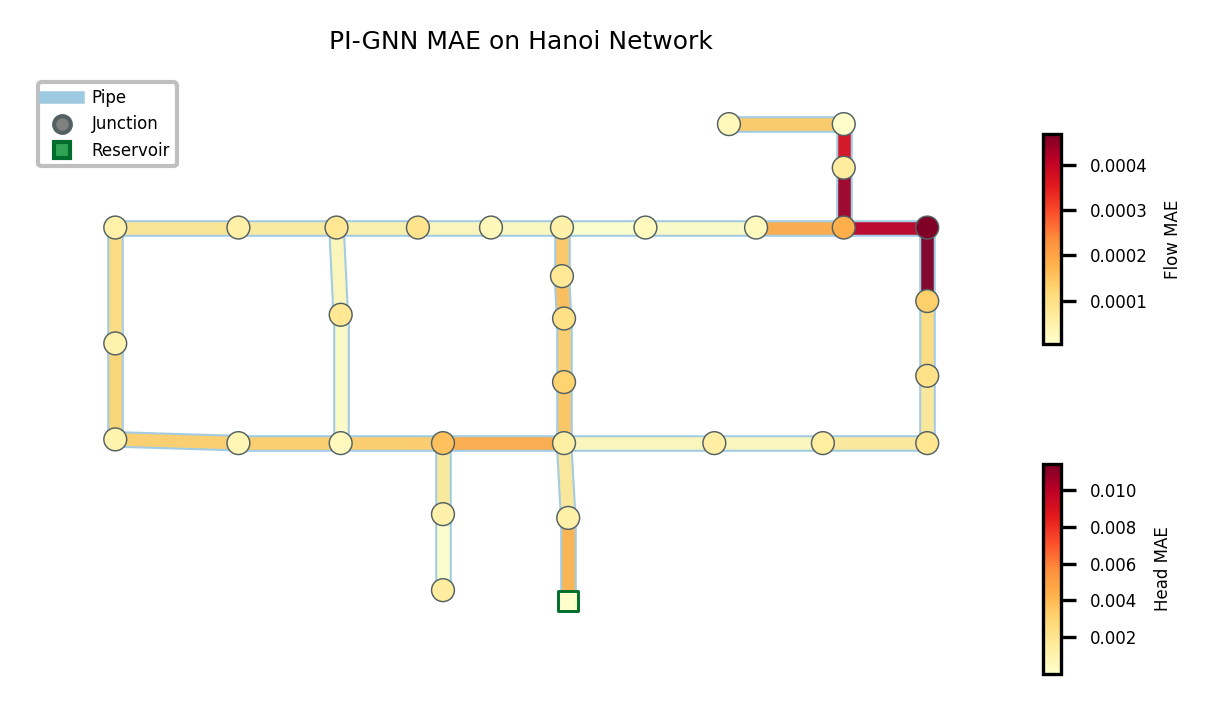

In [140]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
from matplotlib.lines import Line2D
import networkx as nx

fig, ax = plt.subplots(1, 1, figsize=(5, 2.5), dpi=300)
plt.title("PI-GNN MAE on "+network.capitalize()+" Network", fontsize=6, pad=6)

# Node categories
n_nodes = g.X.shape[1]
reservoir_nodes_idx = np.where([int(i) for i in g.X[0, :, 4]])[0]
consumer_nodes_idx = np.array([i for i in range(n_nodes) if i not in set(reservoir_nodes_idx)])

# Keep ONLY forward (physical) edges: edge_direct_mask == 1 (feature index 1)
edge_arr_full = g.edge_index[0].detach().cpu().numpy() if hasattr(g.edge_index, "detach") else np.asarray(g.edge_index)
n_edges_total = edge_arr_full.shape[1]
edge_direct = g.edge_attr[0, :n_edges_total, 1].detach().cpu().numpy()
fwd_idx = np.where(edge_direct == 1)[0]           # physical-direction edge indices
edge_arr = edge_arr_full[:, fwd_idx]               # [2, n_phys_edges]
n_phys_edges = edge_arr.shape[1]
edge_list = [tuple(map(int, e)) for e in edge_arr.T]
pump_mask_unique = g.edge_attr[0, fwd_idx, 3].detach().cpu().abs().long().numpy()

# Coordinates
coords = np.array([(c[0], c[1]) for c in g.node_coords], dtype=float)
x, y = coords[:, 0], coords[:, 1]
xn = (x - x.min()) / (x.max() - x.min() + 1e-12)
yn = (y - y.min()) / (y.max() - y.min() + 1e-12)
x_plot = 0.06 + 1.92 * xn
y_plot = 0.02 + 0.96 * yn
pos = {idx: (x_plot[idx], y_plot[idx]) for idx in range(n_nodes)}

G = nx.Graph()
G.add_nodes_from(range(n_nodes))
G.add_edges_from(edge_list)

pipe_edges = [edge_list[i] for i in range(n_phys_edges) if pump_mask_unique[i] == 0]
pump_edges = [edge_list[i] for i in range(n_phys_edges) if pump_mask_unique[i] != 0]

# --- Flow errors: forward edges only (abs removes sign issues) ---
def _to_np(t):
    if t is None: return None
    a = t.cpu().numpy() if hasattr(t, "cpu") else np.asarray(t)
    return a[..., 0] if a.ndim == 3 else a

fp_np = _to_np(flows_pred)   # [T, 2*n_phys_edges]
fg_np = _to_np(flows_gt)     # [T, 2*n_phys_edges]
flow_errors = np.abs(fp_np[:, fwd_idx] - fg_np[:, fwd_idx]).mean(axis=0)  # [n_phys_edges]
pipe_errors = flow_errors[pump_mask_unique == 0]
pump_errors = flow_errors[pump_mask_unique == 1]
edge_vmin, edge_vmax = flow_errors.min(), flow_errors.max()
edge_cmap = mcm.YlOrRd
edge_norm = mcolors.Normalize(vmin=edge_vmin, vmax=edge_vmax)

# --- Head errors (nodes) ---
node_errors = torch.abs(heads_pred - heads_gt).mean(dim=0).squeeze().cpu().numpy()
node_vmin, node_vmax = node_errors.min(), node_errors.max()
node_cmap = mcm.YlOrRd
node_norm = mcolors.Normalize(vmin=node_vmin, vmax=node_vmax)

# Pipe-like rendering (outer stroke + inner stroke colored by flow error)
nx.draw_networkx_edges(
    G, pos=pos, edgelist=pipe_edges,
    width=4, edge_color="#9ecae1", alpha=0.95, ax=ax
)
nx.draw_networkx_edges(
    G, pos=pos, edgelist=pipe_edges,
    width=3, edge_color=pipe_errors, edge_cmap=edge_cmap,
    edge_vmin=edge_vmin, edge_vmax=edge_vmax, alpha=0.95, ax=ax
)

# Pumps highlighted and colored by flow error
if len(pump_edges) > 0:
    nx.draw_networkx_edges(
        G, pos=pos, edgelist=pump_edges,
        width=6.6, edge_color="#fdd0a2", alpha=0.98, ax=ax
    )
    nx.draw_networkx_edges(
        G, pos=pos, edgelist=pump_edges,
        width=3.2, edge_color=pump_errors, edge_cmap=edge_cmap,
        edge_vmin=edge_vmin, edge_vmax=edge_vmax, alpha=0.98, ax=ax
    )

# Nodes colored by head error
nx.draw_networkx_nodes(
    G, pos=pos,
    nodelist=consumer_nodes_idx.tolist(),
    node_color=node_errors[consumer_nodes_idx],
    cmap=node_cmap, vmin=node_vmin, vmax=node_vmax,
    node_size=30, linewidths=0.35, edgecolors="#536163", ax=ax
)
nx.draw_networkx_nodes(
    G, pos=pos,
    nodelist=reservoir_nodes_idx.tolist(),
    node_color=node_errors[reservoir_nodes_idx],
    cmap=node_cmap, vmin=node_vmin, vmax=node_vmax,
    node_shape="s", node_size=25, linewidths=0.7, edgecolors="#006d2c", ax=ax
)

# --- Two colorbars stacked on the right ---
fig.subplots_adjust(right=0.78)
cax_flow = fig.add_axes([0.80, 0.52, 0.012, 0.28])
cbar_flow = fig.colorbar(mcm.ScalarMappable(cmap=edge_cmap, norm=edge_norm), cax=cax_flow)
cbar_flow.set_label("Flow MAE", fontsize=4)
cbar_flow.ax.tick_params(labelsize=4)

cax_head = fig.add_axes([0.80, 0.08, 0.012, 0.28])
cbar_head = fig.colorbar(mcm.ScalarMappable(cmap=node_cmap, norm=node_norm), cax=cax_head)
cbar_head.set_label("Head MAE", fontsize=4)
cbar_head.ax.tick_params(labelsize=4)

# --- Legend with proxy artists (placed upper-left to avoid colorbars) ---
legend_elements = [
    Line2D([0], [0], color="#9ecae1", linewidth=3, label="Pipe"),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#808080',
           markeredgecolor='#536163', markersize=4, label="Junction"),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='#31a354',
           markeredgecolor='#006d2c', markersize=4, label="Reservoir"),
]
if len(pump_edges) > 0:
    legend_elements.insert(1, Line2D([0], [0], color="#fdd0a2", linewidth=4, label="Pump"))

legend = ax.legend(handles=legend_elements, loc="upper left", fontsize=4, frameon=True)
legend.get_frame().set_alpha(0.94)
legend.get_frame().set_edgecolor("#BBBBBB")

ax.axis("off")

# plt.savefig(save_dir + "/_graph_" + wds + "_paper.pdf", bbox_inches="tight", dpi=300)
plt.show()


### Animation

In [147]:
from IPython.display import HTML
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as mcm
import matplotlib.animation as animation
from matplotlib.lines import Line2D
from matplotlib.collections import LineCollection
from matplotlib.path import Path
import numpy as np

# ── Half-circle markers: left = GT, right = Pred  (junctions) ────────────────
def _half_circle_path(left: bool) -> Path:
    theta = np.linspace(np.pi/2, 3*np.pi/2, 60) if left else np.linspace(-np.pi/2, np.pi/2, 60)
    arc   = np.column_stack([np.cos(theta), np.sin(theta)])
    verts = np.vstack([arc, [0., 0.], arc[0]])
    codes = [Path.MOVETO] + [Path.LINETO]*(len(arc)-1) + [Path.LINETO, Path.CLOSEPOLY]
    return Path(verts, codes)

# ── Half-square markers: left = GT, right = Pred  (reservoirs) ───────────────
def _half_square_path(left: bool) -> Path:
    if left:   # left half of unit square
        verts = [(-1, -1), (0, -1), (0, 1), (-1, 1), (-1, -1)]
    else:      # right half
        verts = [(0, -1), (1, -1), (1, 1), (0, 1), (0, -1)]
    codes = [Path.MOVETO] + [Path.LINETO]*3 + [Path.CLOSEPOLY]
    return Path(verts, codes)

mk_c_gt   = _half_circle_path(left=True)    # junction  – GT   (left)
mk_c_pred = _half_circle_path(left=False)   # junction  – Pred (right)
mk_r_gt   = _half_square_path(left=True)    # reservoir – GT   (left)
mk_r_pred = _half_square_path(left=False)   # reservoir – Pred (right)

# ── Network layout ─────────────────────────────────────────────────────────────
n_nodes = g.X.shape[1]
reservoir_nodes_idx = np.where([int(i) for i in g.X[0, :, 4]])[0]
consumer_nodes_idx  = np.array([i for i in range(n_nodes)
                                  if i not in set(reservoir_nodes_idx.tolist())])

edge_arr_full = (g.edge_index[0].detach().cpu().numpy()
                 if hasattr(g.edge_index, "detach") else np.asarray(g.edge_index))
n_edges_total = edge_arr_full.shape[1]

# Keep ONLY forward (physical) edges: edge_direct_mask == 1 (feature index 1)
edge_direct = g.edge_attr[0, :n_edges_total, 1].detach().cpu().numpy()
fwd_idx = np.where(edge_direct == 1)[0]

edge_arr    = edge_arr_full[:, fwd_idx]
n_phys_edges = edge_arr.shape[1]
edge_list   = [tuple(map(int, e)) for e in edge_arr.T]
pump_mask_u = g.edge_attr[0, fwd_idx, 3].detach().cpu().abs().long().numpy()

coords = np.array([(c[0], c[1]) for c in g.node_coords], dtype=float)
xn = (coords[:, 0] - coords[:, 0].min()) / (coords[:, 0].max() - coords[:, 0].min() + 1e-12)
yn = (coords[:, 1] - coords[:, 1].min()) / (coords[:, 1].max() - coords[:, 1].min() + 1e-12)
xp = 0.06 + 1.92 * xn
yp = 0.02 + 0.96 * yn
pos = {i: (xp[i], yp[i]) for i in range(n_nodes)}

c_idx = consumer_nodes_idx.tolist()
r_idx = reservoir_nodes_idx.tolist()

# ── Tensor → numpy ────────────────────────────────────────────────────────────
def _to_np(t):
    if t is None: return None
    a = t.cpu().numpy() if hasattr(t, "cpu") else np.asarray(t)
    return a[..., 0] if a.ndim == 3 else a

n_samples = 3*48
hp_full = _to_np(heads_pred[:n_samples])
hg_full = _to_np(heads_gt[:n_samples])
fp_full = _to_np(flows_pred[:n_samples])[:, fwd_idx]
fg_full = _to_np(flows_gt[:n_samples])[:, fwd_idx]

# ── Normalize relative to mean (show oscillation around mean state) ────────────
hp = hp_full - hp_full.mean(0)
hg = hg_full - hg_full.mean(0)
fp = fp_full - fp_full.mean(0)
fg = fg_full - fg_full.mean(0)

frames = list(range(n_samples))

# ── Symmetric diverging normalization ─────────────────────────────────────────
head_abs = max(abs(np.concatenate([hp, hg]).min()), abs(np.concatenate([hp, hg]).max()))
head_vmin, head_vmax = -head_abs, head_abs
head_cmap = mcm.Blues
head_norm = mcolors.Normalize(vmin=head_vmin, vmax=head_vmax)

_fstack = np.concatenate([fp, fg])
flow_abs  = max(abs(_fstack.min()), abs(_fstack.max()))
flow_vmin, flow_vmax = -flow_abs, flow_abs
flow_cmap = mcm.Blues
flow_norm = mcolors.Normalize(vmin=flow_vmin, vmax=flow_vmax)

pipe_mask = pump_mask_u == 0
pump_mask = pump_mask_u != 0

# ── Parallel edge segments ────────────────────────────────────────────────────
OFFSET = 0.006
gt_segs, pr_segs = [], []
for u, v in edge_list:
    pu, pv = np.array(pos[u]), np.array(pos[v])
    d    = pv - pu
    perp = np.array([-d[1], d[0]]) / (np.linalg.norm(d) + 1e-12) * OFFSET
    gt_segs.append([pu + perp, pv + perp])
    pr_segs.append([pu - perp, pv - perp])

def _split(segs, mask):
    return [segs[i] for i in range(n_phys_edges) if mask[i]]

pg_segs = _split(gt_segs, pipe_mask);  pp_segs = _split(pr_segs, pipe_mask)
kg_segs = _split(gt_segs, pump_mask);  kp_segs = _split(pr_segs, pump_mask)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 3), dpi=150)
fig.subplots_adjust(left=0.01, right=0.72, top=0.88, bottom=0.02)

def _lc(segs, lw, z=2):
    lc = LineCollection(segs, linewidths=lw, cmap=flow_cmap, norm=flow_norm, zorder=z)
    ax.add_collection(lc)
    return lc

lc_pg = _lc(pg_segs, 2.5)
lc_pp = _lc(pp_segs, 2.5)
lc_kg = _lc(kg_segs, 3.5, z=3) if kg_segs else None
lc_kp = _lc(kp_segs, 3.5, z=3) if kp_segs else None

_kw_c = dict(cmap=head_cmap, norm=head_norm, zorder=4, linewidths=0.3)
_kw_r = dict(cmap=head_cmap, norm=head_norm, zorder=4, linewidths=0.7)

sc_cg = ax.scatter(xp[c_idx], yp[c_idx], c=hg[0, c_idx], marker=mk_c_gt,   s=35, edgecolors="#536163", **_kw_c)
sc_cp = ax.scatter(xp[c_idx], yp[c_idx], c=hp[0, c_idx], marker=mk_c_pred, s=35, edgecolors="#536163", **_kw_c)
sc_rg = ax.scatter(xp[r_idx], yp[r_idx], c=hg[0, r_idx], marker=mk_r_gt,   s=50, edgecolors="#006d2c", **_kw_r) if r_idx else None
sc_rp = ax.scatter(xp[r_idx], yp[r_idx], c=hp[0, r_idx], marker=mk_r_pred, s=50, edgecolors="#006d2c", **_kw_r) if r_idx else None

ttl = ax.set_title("Δ from mean  |  t = 0", fontsize=6, pad=3)

# ── Two colorbars ─────────────────────────────────────────────────────────────
cax_flow = fig.add_axes([0.74, 0.54, 0.018, 0.30])
cb_flow  = fig.colorbar(mcm.ScalarMappable(cmap=flow_cmap, norm=flow_norm), cax=cax_flow)
cb_flow.set_label("ΔFlow (GT / Pred)", fontsize=4.5)
cb_flow.ax.tick_params(labelsize=4)

cax_head = fig.add_axes([0.74, 0.12, 0.018, 0.30])
cb_head  = fig.colorbar(mcm.ScalarMappable(cmap=head_cmap, norm=head_norm), cax=cax_head)
cb_head.set_label("ΔHead (GT / Pred)", fontsize=4.5)
cb_head.ax.tick_params(labelsize=4)

# ── Legend ────────────────────────────────────────────────────────────────────
leg_handles = [
    Line2D([0],[0], color="#888888", lw=2,               label="Pipe  ◀GT  Pred▶"),
    Line2D([0],[0], marker=mk_c_gt,  color='w', markerfacecolor='#aaaaaa',
           markeredgecolor='#536163', ms=5,               label="Junction  ◀GT  Pred▶"),
    Line2D([0],[0], marker=mk_r_gt,  color='w', markerfacecolor='#31a354',
           markeredgecolor='#006d2c', ms=6,               label="Reservoir  ◀GT  Pred▶"),
]
if lc_kg:
    leg_handles.insert(1, Line2D([0],[0], color="#e6550d", lw=3, label="Pump  ◀GT  Pred▶"))

lgnd = fig.legend(handles=leg_handles, loc="lower right",
                  bbox_to_anchor=(0.99, 0.01), fontsize=4, frameon=True,
                  borderaxespad=0)
lgnd.get_frame().set_alpha(0.92)
lgnd.get_frame().set_edgecolor("#BBBBBB")

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(0, 2); ax.set_ylim(0, 1)
ax.axis("off")

# ── Animation ─────────────────────────────────────────────────────────────────
def update(t):
    lc_pg.set_array(fg[t][pipe_mask])
    lc_pp.set_array(fp[t][pipe_mask])
    if lc_kg: lc_kg.set_array(fg[t][pump_mask])
    if lc_kp: lc_kp.set_array(fp[t][pump_mask])
    sc_cg.set_array(hg[t, c_idx]); sc_cp.set_array(hp[t, c_idx])
    if sc_rg: sc_rg.set_array(hg[t, r_idx])
    if sc_rp: sc_rp.set_array(hp[t, r_idx])
    ttl.set_text(f"Δ from mean  |  t = {t}")

ani = animation.FuncAnimation(fig, update, frames=frames, interval=300, blit=False)
plt.close(fig)
HTML(ani.to_jshtml())
